# GDM Dataset – Machine Learning Models for SCBU Admission Prediction

**Bachelor's Thesis Project**

This notebook trains and evaluates three classification models to predict **neonatal SCBU (Special Care Baby Unit) admission**
from maternal clinical features, including Gestational Diabetes Mellitus (GDM) status.

The target variable is highly imbalanced (minority class ≈ 5–6% of records), so each model adopts a different
strategy to handle class imbalance:

| # | Model | Imbalance strategy |
|---|-------|--------------------|
| 1 | **Baseline Random Forest** | None — vanilla RF |
| 2 | **Random Forest + Under-sampling + SMOTE** | Pipeline: RandomUnderSampler → SMOTE → RF with `class_weight='balanced'` |
| 3 | **Random Forest (majority-class downsampling)** | Drop the majority of class-0 rows, then RF with `class_weight='balanced'` |



## 1. Imports & Global Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, precision_recall_curve, average_precision_score
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'Times New Roman',
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

# ── Reproducibility & split configuration ────────────────────────────────────
RANDOM_STATE = 123
TEST_SIZE    = 0.3

# ── Dataset path (update to match your local directory) ──────────────────────
DATA_PATH = "data/Dataset Final.csv"

## 2. Shared Data Loading & Pre-processing

All three models start from the same pre-processed dataset (`DataSet Final.csv`, produced in the
data-preparation notebook). The steps below are shared:

1. Drop columns that are redundant or too correlated with others (`Max_Glucose_Value`, `Severely Premature?`, `Parity`)
2. One-Hot Encode the two remaining categorical columns (`Ethnicity`, `OnsetofLabourMethod`)



In [2]:
# ── Helper: shared OHE pre-processing ────────────────────────────────────────
def load_and_encode(path, drop_glucose=True, drop_extra=True):
    """
    Load the united dataset and apply shared pre-processing:
    - Optionally drop Max_Glucose_Value, Severely Premature?, Parity
    - One-Hot Encode Ethnicity and OnsetofLabourMethod (drop first to avoid multicollinearity)
    Returns: (X, y, data_encoded)
    """
    df = pd.read_csv(path)

    #
    #cols_to_drop = []
    #if drop_glucose:
    #    cols_to_drop.append('Max_Glucose_Value')
    #if drop_extra:
    #    # Drop columns that are highly correlated with others already in the dataset
    #    cols_to_drop += ['Severely Premature?', 'Parity']
    #df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

    # One-Hot Encoding of categorical features
    cat_cols = ['Ethnicity', 'OnsetofLabourMethod']
    ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
    encoded = ohe.fit_transform(df[cat_cols])
    encoded_df = pd.DataFrame(
        encoded,
        columns=ohe.get_feature_names_out(cat_cols),
        index=df.index
    )
    df = pd.concat([df.drop(columns=cat_cols), encoded_df], axis=1)

    X = df.drop(columns=['SCBU admission'])
    y = df['SCBU admission']
    return X, y, df


print("Class distribution in full dataset:")
_, y_full, _ = load_and_encode(DATA_PATH)
print(Counter(y_full))
print(f"Minority class ratio: {y_full.mean():.3%}")

Class distribution in full dataset:


FileNotFoundError: [Errno 2] No such file or directory: 'data/Dataset Final.csv'

### 2.1 Shared evaluation helpers

In [ ]:
# ── Reusable confusion matrix plot ───────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """Plot an annotated confusion matrix with counts and percentages."""
    cm = confusion_matrix(y_true, y_pred)
    group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
    group_counts = [f"{v:0.0f}" for v in cm.flatten()]
    group_pcts   = [f"{v:.2%}"  for v in cm.flatten() / np.sum(cm)]
    labels = np.array(
        [f"{n}\n{c}\n{p}" for n, c, p in zip(group_names, group_counts, group_pcts)]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.show()


# ── Reusable precision–recall curve plot ─────────────────────────────────────
def plot_pr_curve(y_true, y_proba, title="Precision-Recall Curve"):
    """Plot the Precision-Recall curve and report Average Precision (AUC-PR)."""
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    avg_precision = average_precision_score(y_true, y_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, lw=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title)
    plt.text(0.55, 0.92, f'Avg Precision = {avg_precision:.2f}',
             fontsize=14,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4'))
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return avg_precision


# ── Full metrics summary ──────────────────────────────────────────────────────
def print_metrics(y_true, y_pred, y_proba, model_name="Model"):
    """Print a concise metrics summary for a binary classifier."""
    print(f"\n{'='*55}")
    print(f"  {model_name} – Results")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred,
                                target_names=['Not admitted', 'SCBU Admitted']))
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"F1 Score  : {f1_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"AUC-ROC   : {roc_auc_score(y_true, y_proba):.4f}")

## 3. Model 1 – Baseline Random Forest

### Rationale
A vanilla Random Forest with **no resampling** and no class-weight adjustment serves as the baseline.
`Max_Glucose_Value` is kept here and imputed with the **median** (≈ missing completely at random assumption).

**Expected behaviour:** high accuracy but poor recall on the minority class — the model mostly
predicts the majority class (not admitted).


In [ ]:
# ── Load data – keep glucose, impute NaN with median ─────────────────────────
X_b, y_b, _ = load_and_encode(DATA_PATH, drop_glucose=False, drop_extra=True)
#X_b['Max_Glucose_Value'] = SimpleImputer(strategy='median').fit_transform(
#    X_b[['Max_Glucose_Value']]
#)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b, y_b, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_b
)
print("Training class distribution:", Counter(y_train_b))

Training class distribution: Counter({0: 15480, 1: 904})


In [ ]:
# ── Train baseline RF ─────────────────────────────────────────────────────────
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_baseline.fit(X_train_b, y_train_b)

y_pred_b      = rf_baseline.predict(X_test_b)
y_proba_b     = rf_baseline.predict_proba(X_test_b)[:, 1]

print_metrics(y_test_b, y_pred_b, y_proba_b, "Model 1 – Baseline RF")


  Model 1 – Baseline RF – Results
               precision    recall  f1-score   support

 Not admitted       0.95      1.00      0.97      6635
SCBU Admitted       0.83      0.15      0.26       387

     accuracy                           0.95      7022
    macro avg       0.89      0.58      0.62      7022
 weighted avg       0.95      0.95      0.94      7022

Accuracy  : 0.9516
F1 Score  : 0.2576
Precision : 0.8310
Recall    : 0.1525
AUC-ROC   : 0.7644


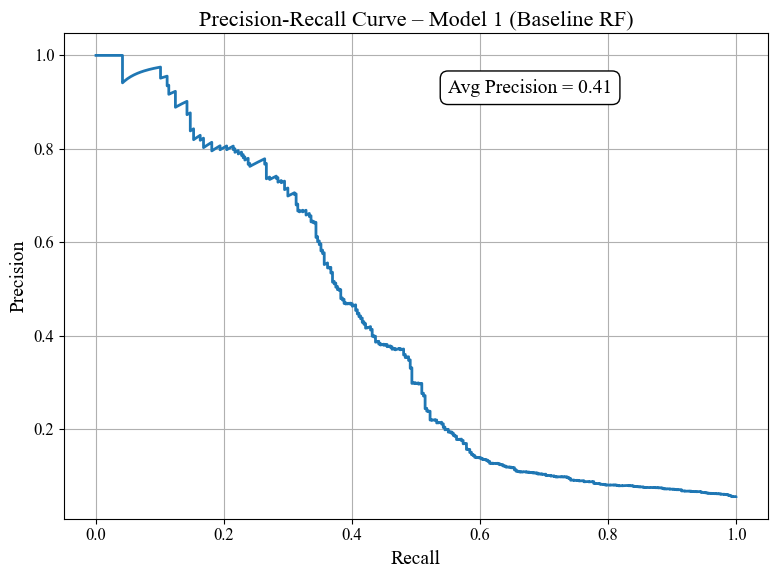

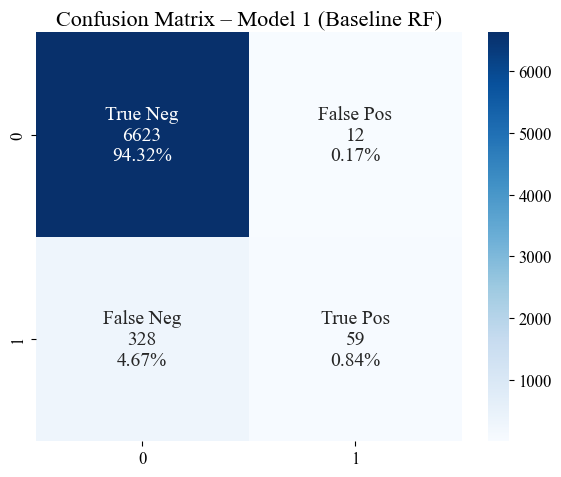

In [ ]:
avg_prec_b = plot_pr_curve(y_test_b, y_proba_b, "Precision-Recall Curve – Model 1 (Baseline RF)")
plot_confusion_matrix(y_test_b, y_pred_b, "Confusion Matrix – Model 1 (Baseline RF)")

## 4. Model 2 – Random Forest with Under-sampling + SMOTE

### Rationale
The baseline heavily under-predicts the minority class. This model addresses class imbalance with a
two-step resampling **pipeline** applied inside cross-validation to avoid data leakage:

1. **RandomUnderSampler** reduces the majority class to `minority / majority = 0.2`
2. **SMOTE** then over-samples the minority class to `minority / majority = 0.8`, generating
   synthetic neighbours via k-NN interpolation
3. **Random Forest** with `class_weight='balanced'` provides a further internal correction

The pipeline is wrapped in `StratifiedKFold` cross-validation so that resampling only ever
sees training folds, preventing any synthetic samples from leaking into the validation fold.

**Key hyper-parameters:**

| Parameter | Value | Reason |
|-----------|-------|--------|
| `UNDER_SAMPLING_STRATEGY` | 0.2 | Keep 5× more majority samples than minority after undersampling |
| `SMOTE_SAMPLING_STRATEGY` | 0.8 | Bring minority up to 80 % of majority size |
| `k_neighbors` (SMOTE) | 10 | Wider neighbourhood for smoother synthetic samples |
| `max_depth` | 5 | Regularise depth to reduce overfitting on synthetic data |


In [ ]:
UNDER_STRATEGY = 0.2
SMOTE_STRATEGY = 0.8

# ── Load data – drop glucose to avoid imputation noise ───────────────────────
X_s, y_s, _ = load_and_encode(DATA_PATH, drop_glucose=True, drop_extra=True)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_s, y_s, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_s
)
print("Training class distribution:", Counter(y_train_s))

# Inspect resampled distributions before the full pipeline fit
rus_inspect   = RandomUnderSampler(sampling_strategy=UNDER_STRATEGY, random_state=RANDOM_STATE)
smote_inspect = SMOTE(sampling_strategy=SMOTE_STRATEGY,  random_state=RANDOM_STATE, k_neighbors=10)

X_rus,   y_rus   = rus_inspect.fit_resample(X_train_s, y_train_s)
X_smote, y_smote = smote_inspect.fit_resample(X_rus, y_rus)

print(f"After RandomUnderSampler : {Counter(y_rus)}")
print(f"After SMOTE              : {Counter(y_smote)}")

Training class distribution: Counter({0: 15480, 1: 904})
After RandomUnderSampler : Counter({0: 4520, 1: 904})
After SMOTE              : Counter({0: 4520, 1: 3616})


In [ ]:
# ── Cross-validation on the full resampling + RF pipeline ────────────────────
pipeline_smote = ImbPipeline([
    ('under', RandomUnderSampler(sampling_strategy=UNDER_STRATEGY, random_state=RANDOM_STATE)),
    ('smote', SMOTE(sampling_strategy=SMOTE_STRATEGY,   random_state=RANDOM_STATE, k_neighbors=10)),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_recall = cross_val_score(pipeline_smote, X_s, y_s, cv=cv, scoring='recall', n_jobs=-1)
print(f"Cross-val Recall: {cv_recall.mean():.3f}  (±{cv_recall.std():.3f})")

Cross-val Recall: 0.492  (±0.023)


In [ ]:
# ── Final fit and evaluation on hold-out test set ────────────────────────────
pipeline_smote.fit(X_train_s, y_train_s)

y_pred_s  = pipeline_smote.predict(X_test_s)
y_proba_s = pipeline_smote.predict_proba(X_test_s)[:, 1]

print_metrics(y_test_s, y_pred_s, y_proba_s, "Model 2 – RF + Under-sampling + SMOTE")


  Model 2 – RF + Under-sampling + SMOTE – Results
               precision    recall  f1-score   support

 Not admitted       0.97      0.94      0.96      6635
SCBU Admitted       0.33      0.48      0.39       387

     accuracy                           0.92      7022
    macro avg       0.65      0.71      0.67      7022
 weighted avg       0.93      0.92      0.92      7022

Accuracy  : 0.9175
F1 Score  : 0.3912
Precision : 0.3298
Recall    : 0.4806
AUC-ROC   : 0.7634


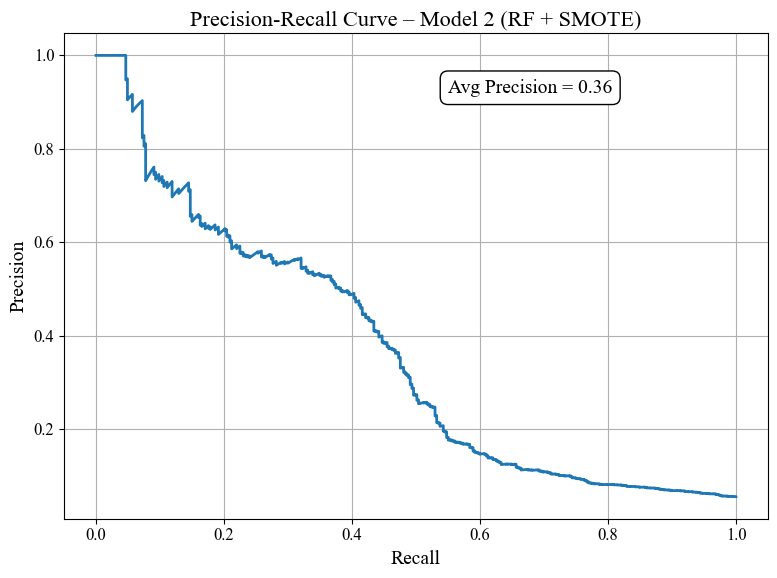

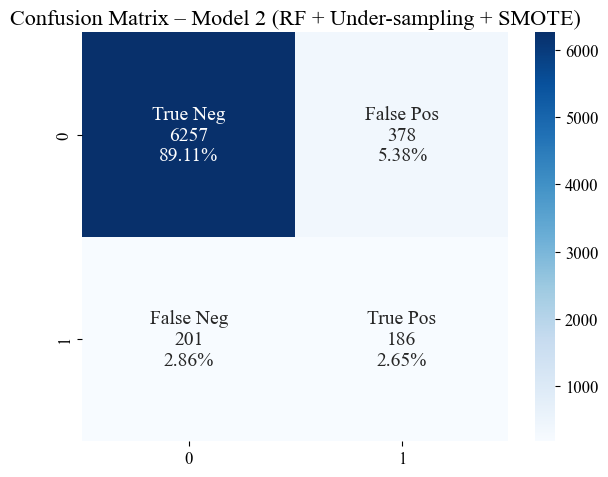

In [ ]:
avg_prec_s = plot_pr_curve(y_test_s, y_proba_s, "Precision-Recall Curve – Model 2 (RF + SMOTE)")
plot_confusion_matrix(y_test_s, y_pred_s, "Confusion Matrix – Model 2 (RF + Under-sampling + SMOTE)")

## 5. Model 3 – Random Forest with Majority-Class Downsampling

### Rationale
Instead of generating synthetic samples, this approach **removes** the majority of the class-0 rows
before training, drastically reducing the imbalance ratio without adding artificial data.

The downsampling threshold is chosen so that the dataset remains large enough to be representative
while the imbalance ratio becomes manageable for the classifier. `class_weight='balanced'` is kept
as an additional correction.

**Trade-off:** information loss from discarding real samples, but no synthetic artefacts and
simpler to interpret than SMOTE-augmented data.


In [ ]:
# ── Load data – drop glucose ──────────────────────────────────────────────────
X_d, y_d, df_d = load_and_encode(DATA_PATH, drop_glucose=True, drop_extra=True)
df_d['SCBU admission'] = y_d.values  # re-attach target for row-level filtering

print("Original class distribution:", Counter(y_d))

# Identify majority-class rows and keep only a manageable subset.
# The threshold below mirrors the original script: drop up to 20 000 class-0 rows.
MAX_DROP = 20_000
zero_rows = df_d[df_d['SCBU admission'] == 0]

if len(zero_rows) >= MAX_DROP:
    rows_to_drop = zero_rows.sample(n=MAX_DROP, random_state=RANDOM_STATE).index
    df_d = df_d.drop(index=rows_to_drop)
    print(f"Dropped {MAX_DROP} majority-class rows.")
else:
    print(f"Only {len(zero_rows)} majority-class rows available — no dropping performed.")

X_d = df_d.drop(columns=['SCBU admission'])
y_d = df_d['SCBU admission']
print("Class distribution after downsampling:", Counter(y_d))
print(f"New minority class ratio: {y_d.mean():.3%}")

Original class distribution: Counter({0: 22115, 1: 1291})
Dropped 20000 majority-class rows.
Class distribution after downsampling: Counter({0: 2115, 1: 1291})
New minority class ratio: 37.904%


In [ ]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d, y_d, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_d
)
print("Training class distribution:", Counter(y_train_d))

# Cross-validation to estimate generalisation recall
rf_down = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_recall_d = cross_val_score(rf_down, X_d, y_d, cv=cv, scoring='recall', n_jobs=-1)
print(f"Cross-val Recall: {cv_recall_d.mean():.3f}  (±{cv_recall_d.std():.3f})")

Training class distribution: Counter({0: 1480, 1: 904})
Cross-val Recall: 0.571  (±0.028)


In [ ]:
# ── Final fit on training set ─────────────────────────────────────────────────
rf_down.fit(X_train_d, y_train_d)

y_pred_d  = rf_down.predict(X_test_d)
y_proba_d = rf_down.predict_proba(X_test_d)[:, 1]

print_metrics(y_test_d, y_pred_d, y_proba_d, "Model 3 – RF with Majority Downsampling")


  Model 3 – RF with Majority Downsampling – Results
               precision    recall  f1-score   support

 Not admitted       0.77      0.93      0.84       635
SCBU Admitted       0.82      0.56      0.66       387

     accuracy                           0.79      1022
    macro avg       0.80      0.74      0.75      1022
 weighted avg       0.79      0.79      0.77      1022

Accuracy  : 0.7857
F1 Score  : 0.6626
Precision : 0.8206
Recall    : 0.5556
AUC-ROC   : 0.8000


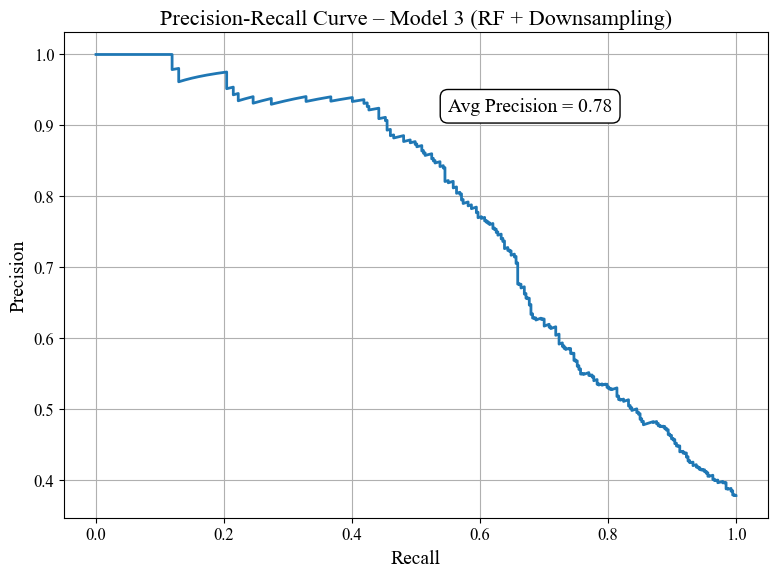

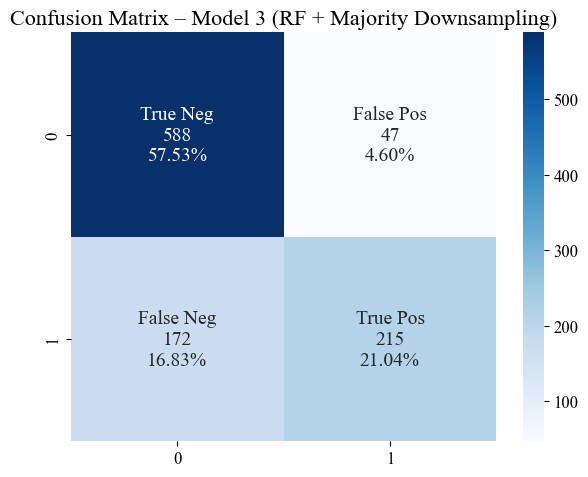

In [ ]:
avg_prec_d = plot_pr_curve(y_test_d, y_proba_d, "Precision-Recall Curve – Model 3 (RF + Downsampling)")
plot_confusion_matrix(y_test_d, y_pred_d, "Confusion Matrix – Model 3 (RF + Majority Downsampling)")

## 6. Model Comparison

Summary table comparing the three models on the hold-out test set.

> ⚠️ **Note on comparability:** Models 2 and 3 operate on different subsets of the data  
> (Model 3 discards the bulk of class-0 rows), so their test sets are not identical.  
> The metrics below are reported for reference; the PR curves and confusion matrices  
> above give a richer picture of each model's behaviour.


In [ ]:
# ── Rebuild metrics programmatically for the summary table ───────────────────
results = {
    "Model": [
        "1 – Baseline RF",
        "2 – RF + Under + SMOTE",
        "3 – RF + Majority Downsampling",
    ],
    "Precision": [
        precision_score(y_test_b, y_pred_b),
        precision_score(y_test_s, y_pred_s),
        precision_score(y_test_d, y_pred_d),
    ],
    "Recall": [
        recall_score(y_test_b, y_pred_b),
        recall_score(y_test_s, y_pred_s),
        recall_score(y_test_d, y_pred_d),
    ],
    "F1 Score": [
        f1_score(y_test_b, y_pred_b),
        f1_score(y_test_s, y_pred_s),
        f1_score(y_test_d, y_pred_d),
    ],
    "AUC-ROC": [
        roc_auc_score(y_test_b, y_proba_b),
        roc_auc_score(y_test_s, y_proba_s),
        roc_auc_score(y_test_d, y_proba_d),
    ],
    "Accuracy": [
        accuracy_score(y_test_b, y_pred_b),
        accuracy_score(y_test_s, y_pred_s),
        accuracy_score(y_test_d, y_pred_d),
    ],
}

df_results = pd.DataFrame(results).set_index("Model")
df_results = df_results.round(4)
df_results

,Precision,Recall,F1 Score,AUC-ROC,Accuracy
Model,,,,,
1 – Baseline RF,0.8310,0.1525,0.2576,0.7644,0.9516
2 – RF + Under + SMOTE,0.3298,0.4806,0.3912,0.7634,0.9175
3 – RF + Majority Downsampling,0.8206,0.5556,0.6626,0.8000,0.7857


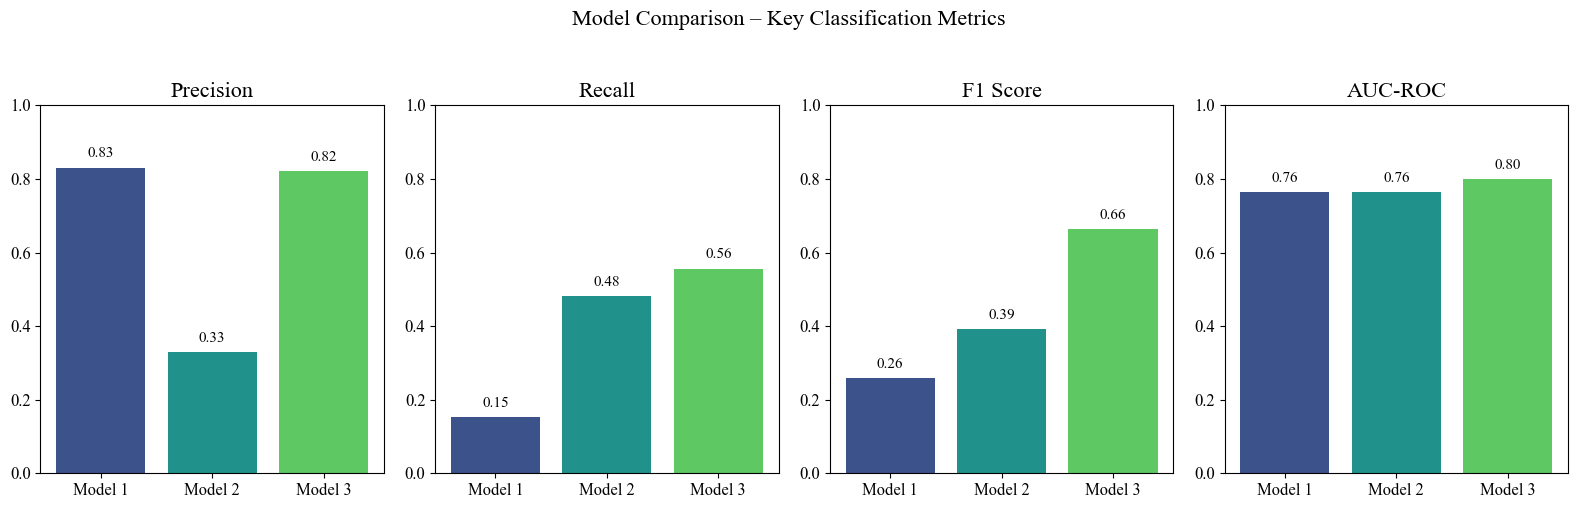

In [ ]:
# ── Bar chart comparison of key metrics ──────────────────────────────────────
metrics_to_plot = ["Precision", "Recall", "F1 Score", "AUC-ROC"]
df_plot = df_results[metrics_to_plot].T

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 5), sharey=False)
colors = sns.color_palette("viridis", n_colors=3)

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(df_results.index, df_results[metric], color=colors)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(
        [f"Model {i+1}" for i in range(len(df_results))],
        rotation=0
    )
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{bar.get_height():.2f}",
            ha='center', va='bottom', fontsize=11
        )

fig.suptitle("Model Comparison – Key Classification Metrics", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 7. Feature Importance

The impurity-based (Gini) feature importances from the baseline RF provide a clean signal
since it was trained on all features without resampling distortion.  
The SMOTE model's importances are also shown for comparison — resampling can shift importance
weights, particularly for features exploited by the k-NN step inside SMOTE.


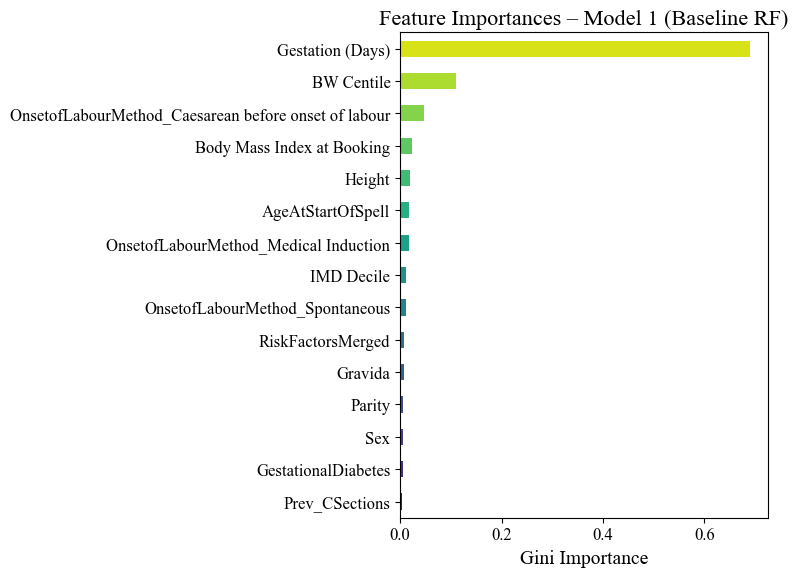

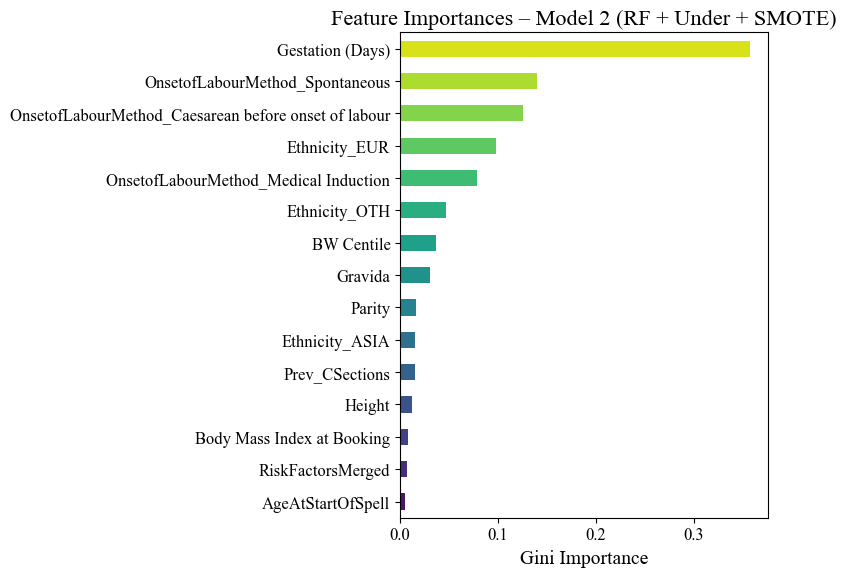

In [ ]:
def plot_feature_importance(model, feature_names, title, top_n=15):
    """Bar chart of the top-N feature importances for a fitted RF model."""
    importances = pd.Series(model.feature_importances_, index=feature_names)
    top = importances.nlargest(top_n).sort_values()

    plt.figure(figsize=(8, 6))
    top.plot(kind='barh', color=sns.color_palette("viridis", top_n))
    plt.xlabel("Gini Importance")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# Baseline RF – fitted directly on X_train_b
plot_feature_importance(
    rf_baseline,
    X_train_b.columns,
    "Feature Importances – Model 1 (Baseline RF)",
)

# RF from the SMOTE pipeline
plot_feature_importance(
    pipeline_smote.named_steps['model'],
    X_train_s.columns,
    "Feature Importances – Model 2 (RF + Under + SMOTE)",
)